# N2 · 受控玩具 transformer: 解剖基座

> 配套 12.1-L3 · 训一个**结构已知**的 tiny transformer (任务: increment-mod-V, 下一个=当前+1)。
> 它的中间激活全可读取 (run_with_cache), 是后续 probing/patching/circuits 的受控解剖对象。
> 受控玩具 = 有 ground truth, 教方法; 真 gpt2 (N1) = 验证可迁移。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))   # 真实模型 helper
import numpy as np, torch
import tiny_transformer as tt
print('tiny transformer: 词表', tt.V, '层', tt.N_LAYERS, '头', tt.N_HEADS)

tiny transformer: 词表 12 层 2 头 4


## 1. 训练玩具 transformer 学 increment-mod-V

In [2]:
torch.manual_seed(0)
Xi, Yi = tt.make_data(2000, seed=0)
print('任务样例 (输入→目标, 下一个=当前+1 mod V):')
print('  输入 ', Xi[0]); print('  目标 ', Yi[0])
model = tt.build_model()
losses = tt.train(model, Xi, Yi, epochs=800)
acc = tt.accuracy(model, *tt.make_data(500, seed=9))
print(f'训练 loss {losses[0]:.3f} → {losses[-1]:.3f}, 测试准确率 {acc:.2f}')

任务样例 (输入→目标, 下一个=当前+1 mod V):
  输入  [10 11  0  1  2  3  4  5]
  目标  [11  0  1  2  3  4  5  6]


训练 loss 2.573 → 0.001, 测试准确率 1.00


## 2. 读取中间激活 (run_with_cache) —— 解剖的入口

In [3]:
logits, cache = model.run_with_cache(torch.tensor(Xi[:1]))
print('可读取的激活 (residual stream / attention / MLP, 每层):')
for k in cache: print(f'    {k:18} {tuple(cache[k].shape)}')
print('\n→ 每个组件从 residual stream 读写信息, 全部可读取 (L3 的逆向工程入口)。')

可读取的激活 (residual stream / attention / MLP, 每层):
    resid_pre          (1, 8, 32)
    attn_out_0         (1, 8, 32)
    attn_pattern_0     (1, 4, 8, 8)
    mlp_out_0          (1, 8, 32)
    resid_post_0       (1, 8, 32)
    attn_out_1         (1, 8, 32)
    attn_pattern_1     (1, 4, 8, 8)
    mlp_out_1          (1, 8, 32)
    resid_post_1       (1, 8, 32)

→ 每个组件从 residual stream 读写信息, 全部可读取 (L3 的逆向工程入口)。


## 3. residual stream 编码了「当前值」吗 (probing 预览)

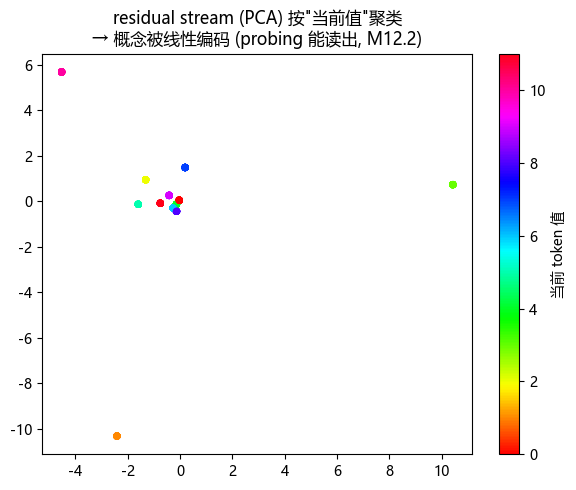

→ residual 里"当前值"这个概念被结构化编码 (同色聚集) → M12.2 线性探针能读出它。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
# 收集很多序列在 最后一层 residual 的激活, 看是否按"当前 token 值"聚类
Xb, Yb = tt.make_data(300, seed=3)
_, cb = model.run_with_cache(torch.tensor(Xb))
resid = cb['resid_post_1'][:, -1, :].numpy()    # 最后位置的 residual (B, d_model)
cur_val = Xb[:, -1]                               # 最后位置的"当前值"
# PCA 到 2D 上色
resid_c = resid - resid.mean(0)
U,S,Vt = np.linalg.svd(resid_c, full_matrices=False)
proj = resid_c @ Vt[:2].T
fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(proj[:,0], proj[:,1], c=cur_val, cmap='hsv', s=18)
plt.colorbar(sc, label='当前 token 值'); ax.set_title('residual stream (PCA) 按"当前值"聚类\n→ 概念被线性编码 (probing 能读出, M12.2)')
plt.tight_layout(); plt.show()
print('→ residual 里"当前值"这个概念被结构化编码 (同色聚集) → M12.2 线性探针能读出它。')

## 4. 反思 (12.1 收口)

你准备好了 mech interp 的解剖基座。带走:
- **受控玩具 transformer**: 结构已知 (increment-mod-V) + 激活全可读 → 教 interp 方法的干净对象。
- **residual stream**: 信息主干, 每组件读写; 概念 (当前值) 被结构化编码 (probing 预览)。
- **两条腿**: 受控玩具 (有 ground truth, 教方法) + 真 gpt2 (N1, 验证可迁移)。

> **M12.1 收口**: mech interp=逆向工程网络; feature/circuit/superposition; 多义神经元是难题; residual stream 是数据总线。
> **交棒 M12.2「probing-and-activations」**: 第一件工具 — 线性探针 + logit lens, 从激活读出概念 (但探针是相关, 引出 12.3 干预)。下一专题 `probing-and-activations`。